## 回顧與說明：掛接 Google Drive

此區塊成功地將您的 Google Drive 掛接到 Colab 環境中，使得您可以讀取或寫入位於 Google Drive 中的檔案。

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 回顧與說明：設定環境與載入 DEM 資料

此區塊完成了必要的 Python 環境設定，包括安裝 `rioxarray` 和 `rasterstats` 等地理空間處理函式庫。隨後，成功載入了位於 Google Drive 的 `dem_20m_hualien.tif` 數位高程模型 (DEM) 資料，並顯示了其基本資訊（形狀、CRS、高程範圍）。

In [45]:
import sys
print(f"Python version: {sys.version}")
!pip install rioxarray rasterstats -q
import rioxarray
import numpy as np
print("✅ rioxarray installed successfully in Colab!")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
✅ rioxarray installed successfully in Colab!


In [46]:
import rioxarray
dem = rioxarray.open_rasterio('/content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 4/Lab 1/GIS_data/dem_20m_hualien.tif')
print(f"✅ DEM loaded! Shape: {dem.shape}, CRS: {dem.rio.crs}")
print(f"Elevation range: {float(dem.min()):.0f} – {float(dem.max()):.0f} m")

✅ DEM loaded! Shape: (1, 7054, 3997), CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Elevation range: -32767 – 3824 m


## 回顧與說明：DEM 視覺化

此區塊將載入的 DEM 資料進行視覺化，以地形色彩圖 (terrain colormap) 展示了高程分佈，讓使用者能直觀地了解研究區域的地形概況。

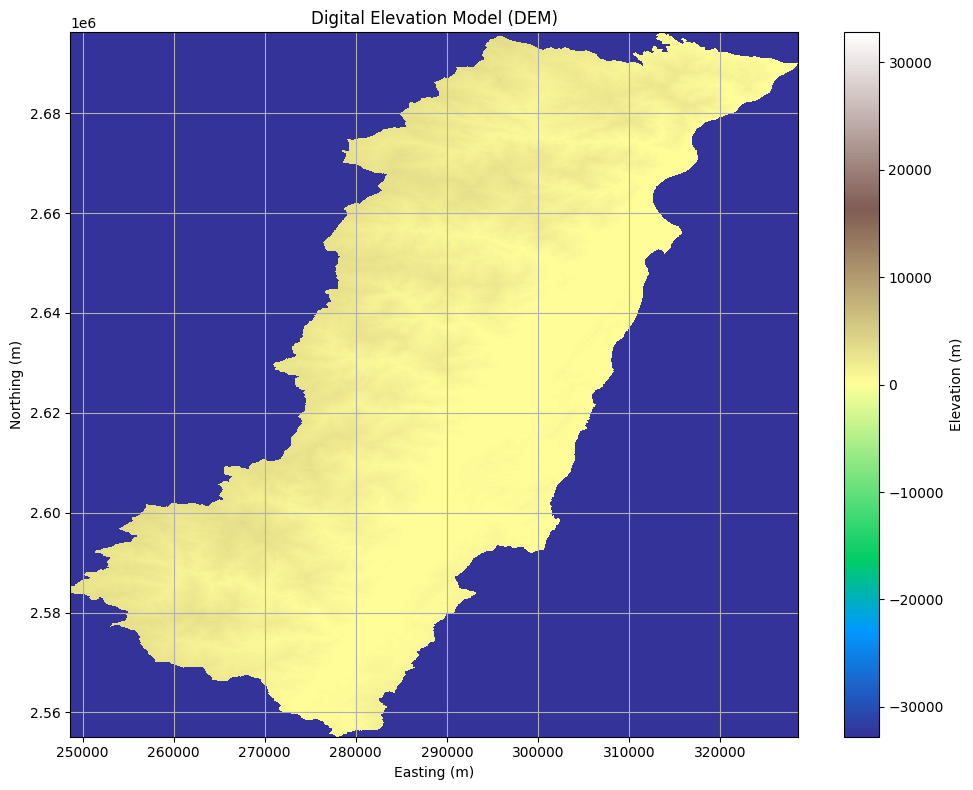

In [47]:
import matplotlib.pyplot as plt

# 移除單一維度的 'band' 軸，以便直接繪圖
dem_to_plot = dem.squeeze()

plt.figure(figsize=(10, 8))
dem_to_plot.plot.imshow(cmap='terrain', cbar_kwargs={'label': 'Elevation (m)'})
plt.title('Digital Elevation Model (DEM)')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 回顧與說明：坡度計算與視覺化

此區塊計算了 DEM 的坡度，坡度值表示地形的陡峭程度，並以色階圖 (viridis colormap) 呈現了坡度分佈，從而識別出平坦與陡峭的區域。
### 計算坡度 (Slope)

接下來，我們將計算 DEM 的坡度。坡度表示地形的陡峭程度。

✅ Slope calculated. Min: 0.00°, Max: 85.45°


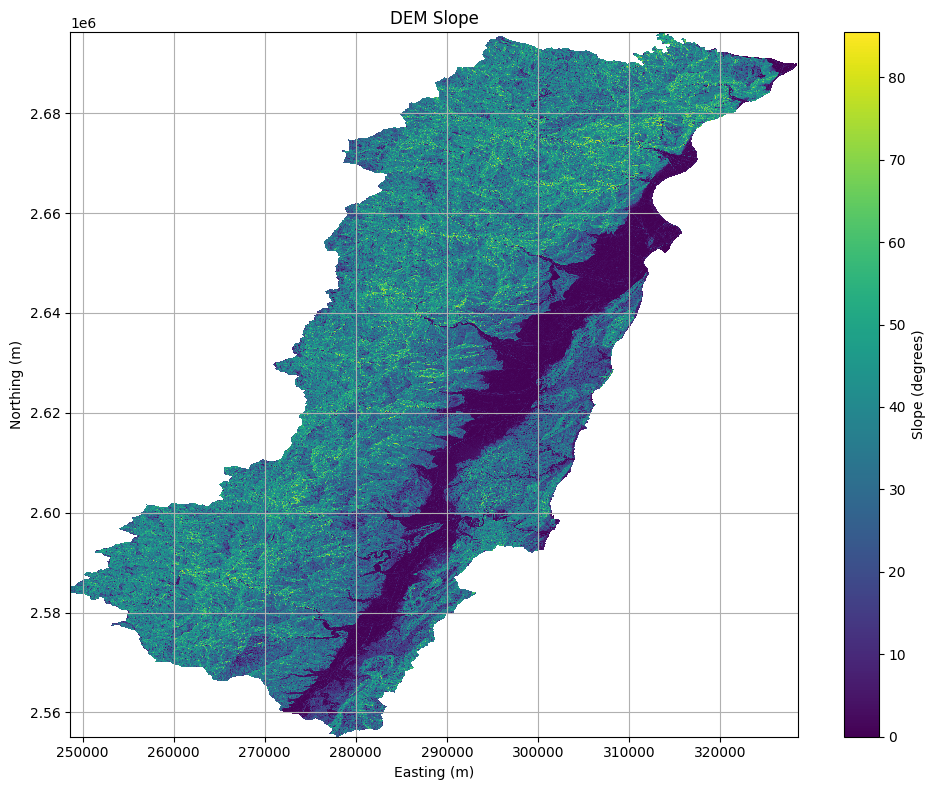

In [48]:
import numpy as np

# 獲取像素大小 (resolution)
# dem.rio.res contains (x_resolution, y_resolution)
x_res = abs(dem.rio.resolution()[0])
y_res = abs(dem.rio.resolution()[1])

# 轉換 DEM 為 NumPy 陣列，並處理 NaN 值 (若有) 或其他異常值，例如 -32767
dem_data = dem.values.squeeze().astype(float)
dem_data[dem_data == -32767] = np.nan # 將 NoData 值轉換為 NaN

# 計算梯度 (derivative) - Horn's algorithm 的簡化版
# fx = (c + 2f + i) - (a + 2d + g) / (8 * x_res)
# fy = (g + 2h + i) - (a + 2b + c) / (8 * y_res)

# 為了簡化，我們先使用 NumPy 的 gradient 函數
# 它計算的是中央差分

# 考慮到 dem_data 已經是 2D 陣列
# np.gradient 預設會計算每個軸的梯度
dz_dy, dz_dx = np.gradient(dem_data, y_res, x_res)

# 計算坡度 (度)
slope_radians = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_degrees = np.degrees(slope_radians)

# 將坡度結果儲存回 xarray.DataArray 格式
slope = dem.squeeze().copy()
slope.values = slope_degrees
slope.name = 'Slope'
slope.attrs['units'] = 'degrees'

print(f"✅ Slope calculated. Min: {np.nanmin(slope_degrees):.2f}°, Max: {np.nanmax(slope_degrees):.2f}°")

# 視覺化坡度
plt.figure(figsize=(10, 8))
slope.plot.imshow(cmap='viridis', cbar_kwargs={'label': 'Slope (degrees)'})
plt.title('DEM Slope')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 回顧與說明：坡向計算與視覺化

此區塊計算了 DEM 的坡向，坡向值表示坡面朝向的方向，並以色環圖 (hsv colormap) 視覺化，協助判斷地形的方位。
### 計算坡向 (Aspect)

接下來，我們將計算 DEM 的坡向。坡向表示坡面朝向的方向。

✅ Aspect calculated. Min: 0.00°, Max: 359.99°


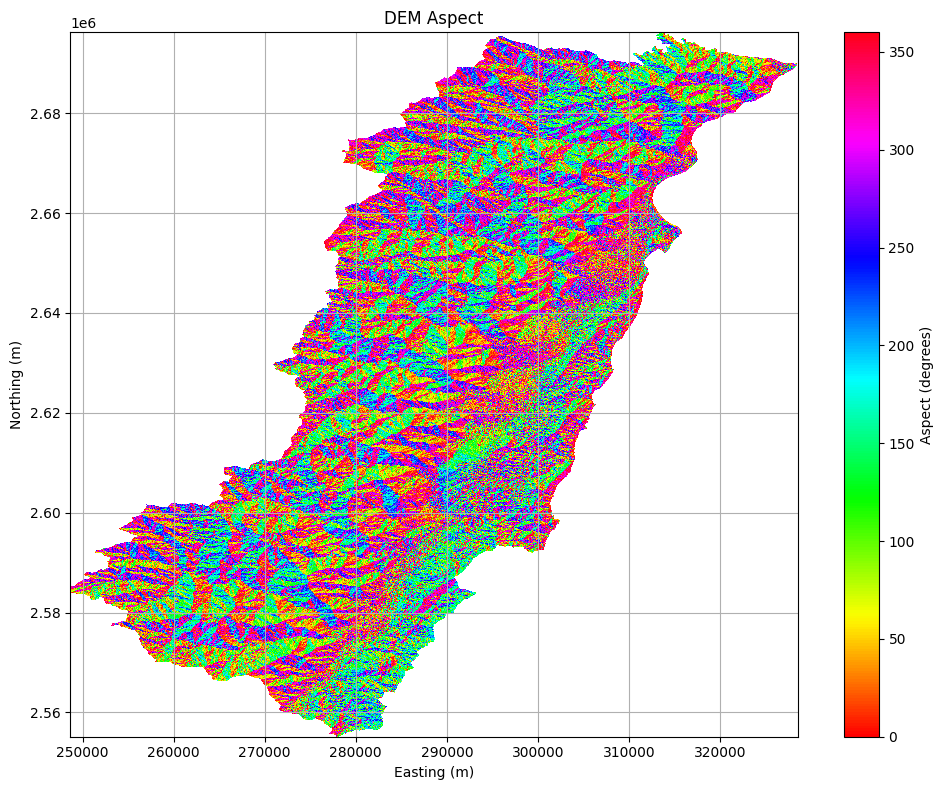

In [49]:
# 繼續使用之前計算的 dz_dx 和 dz_dy

# 計算坡向 (弧度)
aspect_radians = np.arctan2(dz_dy, -dz_dx)

# 將負值調整到 [0, 2*pi) 範圍，並將 NaN 值排除
aspect_radians = np.where(np.isnan(dem_data), np.nan, aspect_radians)
aspect_radians = np.where(aspect_radians < 0, aspect_radians + 2 * np.pi, aspect_radians)

# 轉換為度數
aspect_degrees = np.degrees(aspect_radians)

# 將坡向結果儲存回 xarray.DataArray 格式
aspect = dem.squeeze().copy()
aspect.values = aspect_degrees
aspect.name = 'Aspect'
aspect.attrs['units'] = 'degrees (0-360)'

print(f"✅ Aspect calculated. Min: {np.nanmin(aspect_degrees):.2f}°, Max: {np.nanmax(aspect_degrees):.2f}°")

# 視覺化坡向
plt.figure(figsize=(10, 8))
aspect.plot.imshow(cmap='hsv', cbar_kwargs={'label': 'Aspect (degrees)'})
plt.title('DEM Aspect')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 回顧與說明：坡度重分類與風險評估

此區塊根據預定義的條件，將連續的坡度值重分類為離散的風險等級（低風險、中風險、高風險），並以自定義的三色圖 (紅黃綠) 視覺化，使決策者能更清晰地理解地形風險分佈。
### 坡度重分類 (Slope Reclassification)

為了簡化決策過程，我們將原始的坡度值（0-90°）重分類為更具操作性的風險等級：

*   **0-15°** → 低風險 (Low Risk) → 值為 **1**
*   **15-30°** → 中風險 (Medium Risk) → 值為 **2**
*   **> 30°** → 高風險 (High Risk) → 值為 **3**

✅ Reclassified slope calculated. Levels: [1. 2. 3.]


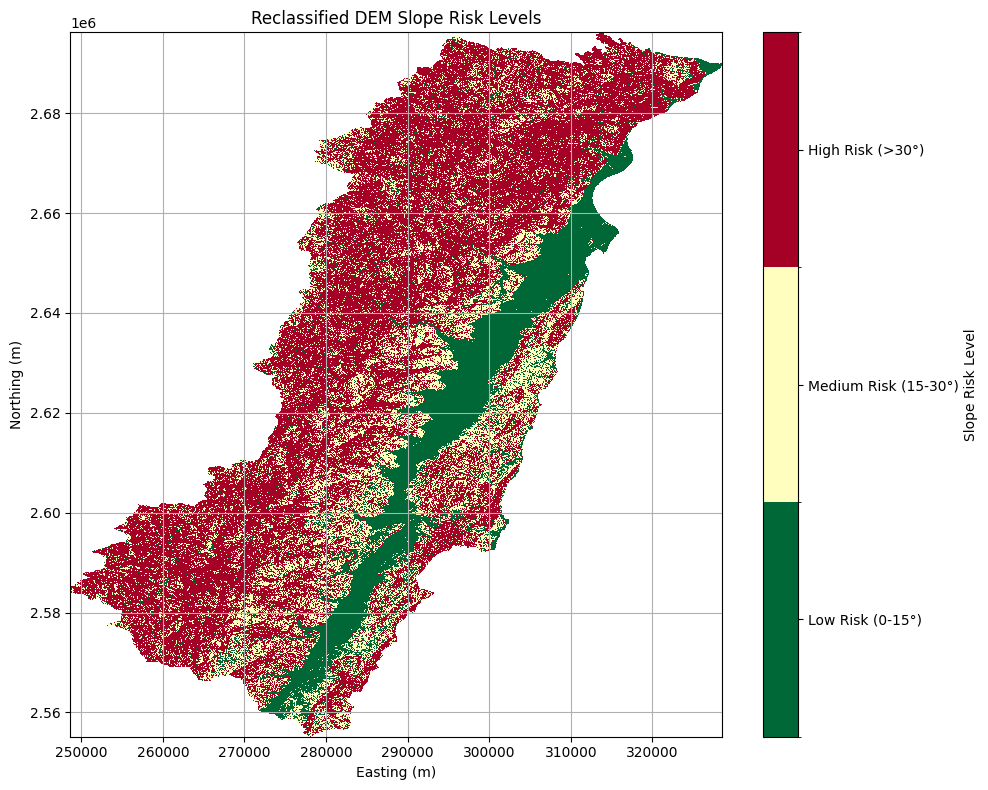

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 定義重分類條件
conditions = [
    (slope_degrees >= 0) & (slope_degrees <= 15),
    (slope_degrees > 15) & (slope_degrees <= 30),
    (slope_degrees > 30)
]

# 定義對應的重分類值
choices = [1, 2, 3]

# 使用 numpy.select 進行重分類
reclassified_slope_values = np.select(conditions, choices, default=np.nan)

# 將重分類結果儲存回 xarray.DataArray 格式
reclassified_slope = dem.squeeze().copy()
reclassified_slope.values = reclassified_slope_values
reclassified_slope.name = 'Reclassified Slope'
reclassified_slope.attrs['units'] = 'Risk Level'

print(f"✅ Reclassified slope calculated. Levels: {np.unique(reclassified_slope_values[~np.isnan(reclassified_slope_values)])}")

# 視覺化重分類後的坡度
plt.figure(figsize=(10, 8))

# 定義顏色對應表和標籤
# 獲取基礎的連續 colormap
base_cmap = plt.colormaps.get_cmap('RdYlGn_r')

# 從連續 colormap 中創建一個 3 個離散顏色的 ListedColormap
# RdYlGn_r 是紅黃綠反轉，所以綠色對應低風險 (1)，紅色對應高風險 (3)
colors = [base_cmap(0.0), base_cmap(0.5), base_cmap(1.0)] # 綠、黃、紅
cmap = ListedColormap(colors)

# 定義邊界，以便正確映射離散值 (1, 2, 3)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N) # cmap.N 現在是 3

cbar_labels = {1: 'Low Risk (0-15°)', 2: 'Medium Risk (15-30°)', 3: 'High Risk (>30°)'}

# 繪圖時需要手動處理色條和標籤
im = reclassified_slope.plot.imshow(cmap=cmap, norm=norm, add_colorbar=False)

# 自定義色條
cbar = plt.colorbar(im, ticks=[1, 2, 3])
cbar.set_ticklabels([cbar_labels[i] for i in sorted(cbar_labels.keys())])
cbar.set_label('Slope Risk Level')

plt.title('Reclassified DEM Slope Risk Levels')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 回顧與說明：坡面陰影計算與視覺化

此區塊計算了 DEM 的坡面陰影，模擬了在特定太陽角度下的地形光照效果，並以灰度圖 (Greys_r colormap) 呈現，增強了地形的立體感和視覺效果。
### 計算坡面陰影 (Hillshade)

坡面陰影是根據地形的高程、坡度、坡向以及太陽的高度角和方位角來模擬地形受光照影響的效果。它可以增強地形的視覺效果，使其看起來更具三維感。

✅ Hillshade calculated. Min: -0.71, Max: 1.00


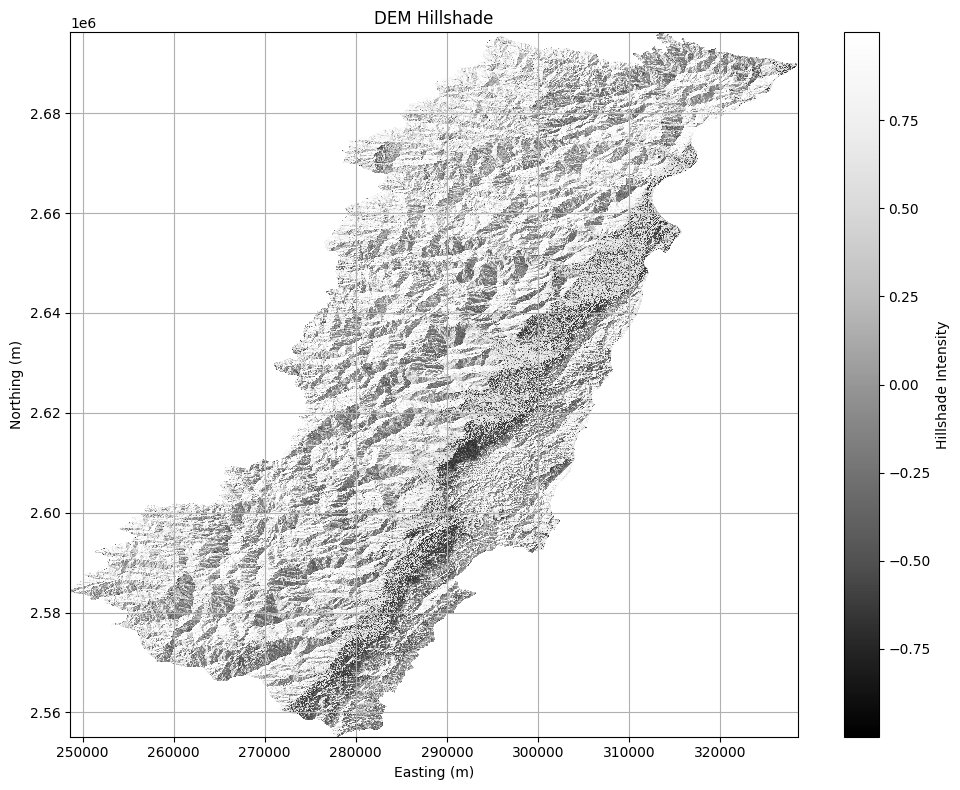

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 定義太陽參數 (可以根據需要調整)
# 這裡使用預設值：方位角 (azimuth) 315 度 (西北方), 高度角 (altitude) 45 度
altitude_degrees = 45
azimuth_degrees = 315

# 將角度轉換為弧度
altitude_radians = np.radians(altitude_degrees)
azimuth_radians = np.radians(azimuth_degrees)

# 計算坡面陰影
# 需要用到之前計算的 dz_dx 和 dz_dy (即地形梯度)

# 將坡度 (slope_radians) 和坡向 (aspect_radians) 準備好
# 確保它們與 dem_data 具有相同的形狀和 NoData 處理

# 處理 NaN 值，確保計算不會受其影響
slope_radians_clean = np.where(np.isnan(dem_data), np.nan, slope_radians)
aspect_radians_clean = np.where(np.isnan(dem_data), np.nan, aspect_radians)

# Hillshade 計算公式
hillshade_values = (
    np.sin(altitude_radians) * np.sin(slope_radians_clean) +
    np.cos(altitude_radians) * np.cos(slope_radians_clean) *
    np.cos(azimuth_radians - aspect_radians_clean)
)

# 將 NaN 設回，以匹配原始數據的範圍
hillshade_values = np.where(np.isnan(dem_data), np.nan, hillshade_values)

# 將結果儲存回 xarray.DataArray 格式
hillshade = dem.squeeze().copy()
hillshade.values = hillshade_values
hillshade.name = 'Hillshade'
hillshade.attrs['units'] = 'intensity (0-1)'

print(f"✅ Hillshade calculated. Min: {np.nanmin(hillshade_values):.2f}, Max: {np.nanmax(hillshade_values):.2f}")

# 視覺化坡面陰影
plt.figure(figsize=(10, 8))
hillshade.plot.imshow(cmap='Greys_r', cbar_kwargs={'label': 'Hillshade Intensity'})
plt.title('DEM Hillshade')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 回顧與說明：`.gitignore` 檔案更新

此區塊檢查並更新了指定的 `.gitignore` 檔案，確保 `.tif` 檔案類型被加入到 Git 忽略清單中，避免大型地理空間影像檔案被提交到版本控制系統。
### 將 `.tif` 加入 `.gitignore`

`.gitignore` 檔案用於指定 Git 應該忽略哪些未被追蹤的檔案。將 `.tif` 加入其中，可以避免大型或不必要的地理空間影像檔案被提交到您的 GitHub 儲存庫。

In [52]:
import os

gitignore_path = '/content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 4/Lab 1/.gitignore'

# 檢查 .gitignore 是否存在
if os.path.exists(gitignore_path):
    # 如果存在，讀取內容
    with open(gitignore_path, 'r') as f:
        content = f.read()

    # 如果 .tif 不在裡面，則新增
    if '.tif' not in content.splitlines():
        with open(gitignore_path, 'a') as f:
            f.write('\n.tif')
        print(f"✅ '.tif' 已成功新增至 {gitignore_path}")
    else:
        print(f"ℹ️ '.tif' 已存在於 {gitignore_path} 中，無需重複新增。")
else:
    # 如果不存在，則建立並寫入 .tif
    with open(gitignore_path, 'w') as f:
        f.write('.tif')
    print(f"✅ 已建立 {gitignore_path} 並新增 '.tif'")

ℹ️ '.tif' 已存在於 /content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 4/Lab 1/.gitignore 中，無需重複新增。
